<a href="https://colab.research.google.com/github/navya8919/-first-project/blob/master/nlp_driven_platform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install textstat nltk spacy matplotlib seaborn wordcloud pandas numpy -q
!python -m spacy download en_core_web_sm -q
print('✅ All libraries installed successfully!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 36.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 94.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ All libraries installed successfully!


In [2]:
import textstat
import nltk
import spacy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [3]:
nltk.download('punkt',                      quiet=True)
nltk.download('punkt_tab',                  quiet=True)
nltk.download('stopwords',                  quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('cmudict',                    quiet=True)

True

In [4]:
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords, cmudict

nlp = spacy.load('en_core_web_sm')
print('✅ All imports successful!')

✅ All imports successful!


In [5]:
sample_text = """
Natural language processing (NLP) is a subfield of linguistics, computer science, and artificial
intelligence concerned with the interactions between computers and human language, in particular
how to program computers to process and analyze large amounts of natural language data. The goal
is a computer capable of understanding the contents of documents, including the contextual nuances
of the language within them.

The technology can then accurately extract information and insights contained in the documents,
as well as categorize and organize the documents themselves. Challenges in natural language
processing frequently involve speech recognition, natural language understanding, and natural
language generation.

NLP is used to analyze text, allowing machines to understand how humans speak. This human-computer
interaction enables real-world applications like automatic text summarization, sentiment analysis,
topic extraction, named entity recognition, parts-of-speech tagging, relationship extraction,
stemming, and more.
"""

text = sample_text.strip()
print(f'📄 Text loaded: {len(text)} characters, {len(text.split())} words')

📄 Text loaded: 1035 characters, 135 words


In [6]:
class ReadabilityScorer:
    """
    NLP-Based Readability Scoring System.
    Computes multiple industry-standard readability formulas
    plus a custom NLP complexity metric.
    """

    def __init__(self, text):
        self.text         = text
        self.doc          = nlp(text)
        self.sentences    = sent_tokenize(text)
        self.words        = word_tokenize(text)
        self.words_clean  = [w for w in self.words if w.isalpha()]
        self.stop_words   = set(stopwords.words('english'))
        self.d            = cmudict.dict()

    def word_count(self):
        return len(self.words_clean)

    def sentence_count(self):
        return len(self.sentences)

    def avg_sentence_length(self):
        return self.word_count() / max(self.sentence_count(), 1)

    def syllable_count_word(self, word):
        word = word.lower()
        if word in self.d:
            return max([len([y for y in pron if y[-1].isdigit()]) for pron in self.d[word]])
        count = 0
        vowels = 'aeiouy'
        word = word.rstrip('e')
        prev_vowel = False
        for char in word:
            is_vowel = char in vowels
            if is_vowel and not prev_vowel:
                count += 1
            prev_vowel = is_vowel
        return max(1, count)

    def total_syllables(self):
        return sum(self.syllable_count_word(w) for w in self.words_clean)

    def complex_word_count(self):
        return sum(1 for w in self.words_clean if self.syllable_count_word(w) >= 3)

    def char_count(self):
        return sum(len(w) for w in self.words_clean)

    def avg_word_length(self):
        return self.char_count() / max(self.word_count(), 1)

    def flesch_reading_ease(self):
        return textstat.flesch_reading_ease(self.text)

    def flesch_kincaid_grade(self):
        return textstat.flesch_kincaid_grade(self.text)

    def gunning_fog(self):
        return textstat.gunning_fog(self.text)

    def smog_index(self):
        return textstat.smog_index(self.text)

    def coleman_liau(self):
        return textstat.coleman_liau_index(self.text)

    def ari(self):
        return textstat.automated_readability_index(self.text)

    def dale_chall(self):
        return textstat.dale_chall_readability_score(self.text)

    def consensus_grade(self):
        return textstat.text_standard(self.text)

    def lexical_diversity(self):
        unique = set(w.lower() for w in self.words_clean)
        return len(unique) / max(len(self.words_clean), 1)

    def pos_distribution(self):
        tags = [token.pos_ for token in self.doc if token.is_alpha]
        return Counter(tags)

    def named_entity_count(self):
        return len(self.doc.ents)

    def noun_phrase_density(self):
        return len(list(self.doc.noun_chunks)) / max(self.sentence_count(), 1)

    def passive_voice_ratio(self):
        passive = sum(1 for sent in self.doc.sents
                      for token in sent if token.dep_ == 'nsubjpass')
        return passive / max(self.sentence_count(), 1)

    def nlp_complexity_score(self):
        asl = min(self.avg_sentence_length() / 30, 1.0) * 30
        awl = min(self.avg_word_length()     / 8,  1.0) * 25
        ld  = self.lexical_diversity()              * 25
        cwr = (self.complex_word_count() / max(self.word_count(), 1)) * 20
        return round(asl + awl + ld + cwr, 2)

    def full_report(self):
        return {
            'Basic Statistics': {
                'Total Words':                  self.word_count(),
                'Total Sentences':              self.sentence_count(),
                'Total Syllables':              self.total_syllables(),
                'Complex Words (3+ syllables)': self.complex_word_count(),
                'Avg Sentence Length':          round(self.avg_sentence_length(), 2),
                'Avg Word Length':              round(self.avg_word_length(), 2),
                'Lexical Diversity (TTR)':      round(self.lexical_diversity(), 4),
                'Named Entities':               self.named_entity_count(),
                'Noun Phrase Density':          round(self.noun_phrase_density(), 2),
                'Passive Voice Ratio':          round(self.passive_voice_ratio(), 4),
            },
            'Readability Scores': {
                'Flesch Reading Ease':          self.flesch_reading_ease(),
                'Flesch-Kincaid Grade':         self.flesch_kincaid_grade(),
                'Gunning Fog Index':            self.gunning_fog(),
                'SMOG Index':                   self.smog_index(),
                'Coleman-Liau Index':           self.coleman_liau(),
                'Automated Readability Index':  self.ari(),
                'Dale-Chall Score':             self.dale_chall(),
                'NLP Complexity Score (Custom)':self.nlp_complexity_score(),
                'Consensus Grade Level':        self.consensus_grade(),
            }
        }

# Run the scorer
scorer = ReadabilityScorer(text)
report = scorer.full_report()

for section, metrics in report.items():
    print(f'\n{"="*50}')
    print(f'  {section}')
    print(f'{"="*50}')
    for k, v in metrics.items():
        print(f'  {k:<40} {v}')


  Basic Statistics
  Total Words                              132
  Total Sentences                          6
  Total Syllables                          280
  Complex Words (3+ syllables)             50
  Avg Sentence Length                      22.0
  Avg Word Length                          6.34
  Lexical Diversity (TTR)                  0.6364
  Named Entities                           2
  Noun Phrase Density                      7.17
  Passive Voice Ratio                      0.1667

  Readability Scores
  Flesch Reading Ease                      1.637500000000017
  Flesch-Kincaid Grade                     18.62055555555556
  Gunning Fog Index                        24.40740740740741
  SMOG Index                               20.10790988173199
  Coleman-Liau Index                       20.34814814814815
  Automated Readability Index              21.185111111111105
  Dale-Chall Score                         13.758648148148149
  NLP Complexity Score (Custom)            65.3
  Conse

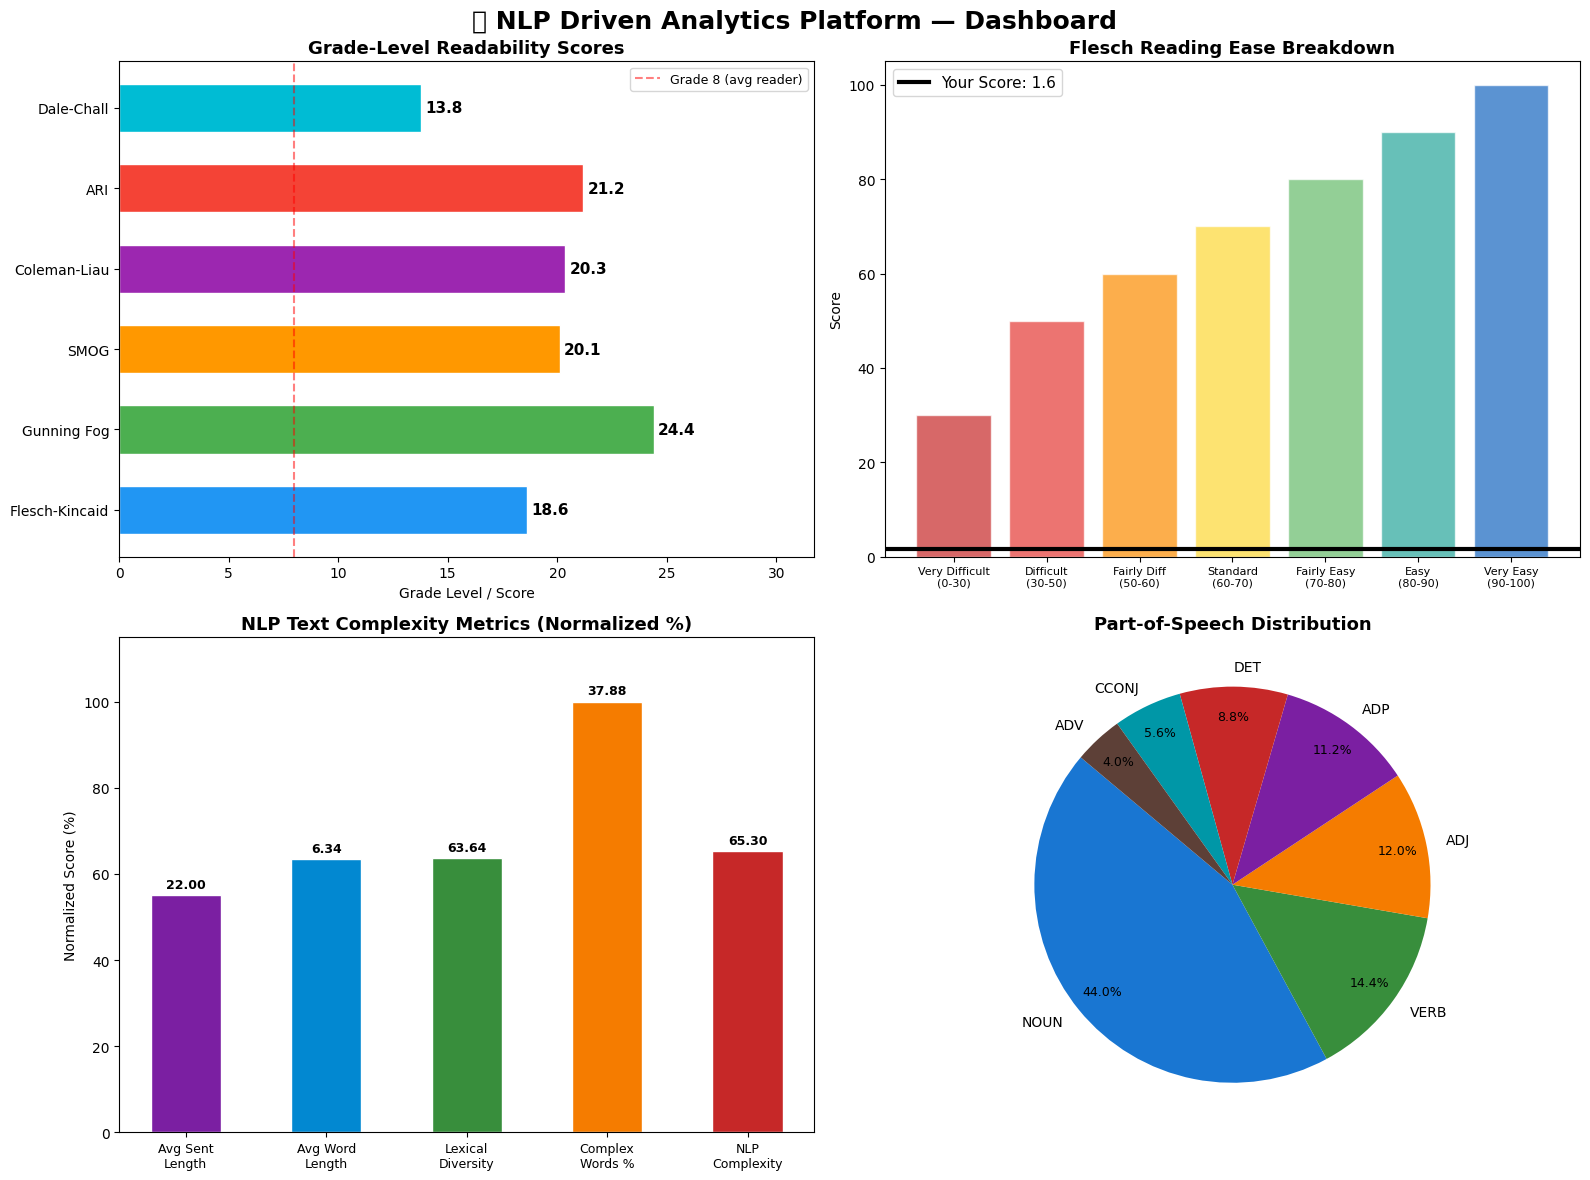

✅ Dashboard saved!


In [7]:
# ─────────────────────────────────────────
# STEP 5: Readability Score Visualization
# ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('🧠 NLP Driven Analytics Platform — Dashboard',
             fontsize=18, fontweight='bold', y=0.98)

scores = report['Readability Scores']
grade_scores = {
    'Flesch-Kincaid': scores['Flesch-Kincaid Grade'],
    'Gunning Fog':    scores['Gunning Fog Index'],
    'SMOG':           scores['SMOG Index'],
    'Coleman-Liau':   scores['Coleman-Liau Index'],
    'ARI':            scores['Automated Readability Index'],
    'Dale-Chall':     scores['Dale-Chall Score'],
}

# Plot 1: Grade-level horizontal bar chart
ax1 = axes[0, 0]
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4']
bars = ax1.barh(list(grade_scores.keys()), list(grade_scores.values()),
                color=colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, grade_scores.values()):
    ax1.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=11, fontweight='bold')
ax1.set_title('Grade-Level Readability Scores', fontsize=13, fontweight='bold')
ax1.set_xlabel('Grade Level / Score')
ax1.axvline(x=8, color='red', linestyle='--', alpha=0.5, label='Grade 8 (avg reader)')
ax1.legend(fontsize=9)
ax1.set_xlim(0, max(grade_scores.values()) * 1.3)

# Plot 2: Flesch Reading Ease gauge
ax2 = axes[0, 1]
fre = scores['Flesch Reading Ease']
categories  = ['Very Difficult\n(0-30)', 'Difficult\n(30-50)', 'Fairly Diff\n(50-60)',
               'Standard\n(60-70)', 'Fairly Easy\n(70-80)', 'Easy\n(80-90)', 'Very Easy\n(90-100)']
thresholds  = [30, 50, 60, 70, 80, 90, 100]
cat_colors  = ['#C62828','#E53935','#FB8C00','#FDD835','#66BB6A','#26A69A','#1565C0']
ax2.bar(categories, thresholds, color=cat_colors, edgecolor='white', alpha=0.7)
ax2.axhline(y=fre, color='black', linewidth=3, linestyle='-', label=f'Your Score: {fre:.1f}')
ax2.set_title('Flesch Reading Ease Breakdown', fontsize=13, fontweight='bold')
ax2.set_ylabel('Score')
ax2.legend(fontsize=11)
ax2.tick_params(axis='x', labelsize=8)

# Plot 3: NLP Complexity Metrics
ax3 = axes[1, 0]
stats = report['Basic Statistics']
metrics_names = ['Avg Sent\nLength', 'Avg Word\nLength', 'Lexical\nDiversity',
                 'Complex\nWords %', 'NLP\nComplexity']
raw_vals = [
    stats['Avg Sentence Length'],
    stats['Avg Word Length'],
    stats['Lexical Diversity (TTR)'] * 100,
    (stats['Complex Words (3+ syllables)'] / max(stats['Total Words'], 1)) * 100,
    scores['NLP Complexity Score (Custom)']
]
norm_vals   = [min(v / mv * 100, 100) for v, mv in zip(raw_vals, [40, 10, 100, 30, 100])]
bar_colors  = ['#7B1FA2','#0288D1','#388E3C','#F57C00','#C62828']
bars3 = ax3.bar(range(len(metrics_names)), norm_vals, color=bar_colors,
                width=0.5, edgecolor='white')
for bar, rv in zip(bars3, raw_vals):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{rv:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3.set_xticks(range(len(metrics_names)))
ax3.set_xticklabels(metrics_names, fontsize=9)
ax3.set_title('NLP Text Complexity Metrics (Normalized %)', fontsize=13, fontweight='bold')
ax3.set_ylabel('Normalized Score (%)')
ax3.set_ylim(0, 115)

# Plot 4: POS Distribution Pie
ax4 = axes[1, 1]
pos_dist = scorer.pos_distribution()
top_pos  = dict(sorted(pos_dist.items(), key=lambda x: x[1], reverse=True)[:7])
pie_colors = ['#1976D2','#388E3C','#F57C00','#7B1FA2','#C62828','#0097A7','#5D4037']
wedges, texts, autotexts = ax4.pie(
    top_pos.values(), labels=top_pos.keys(),
    autopct='%1.1f%%', colors=pie_colors, startangle=140, pctdistance=0.85
)
for t in autotexts:
    t.set_fontsize(9)
ax4.set_title('Part-of-Speech Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('readability_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard saved!')

In [8]:
def interpret_flesch(score):
    if   score >= 90: return '✅ Very Easy (5th grade)'
    elif score >= 80: return '✅ Easy (6th grade)'
    elif score >= 70: return '⚡ Fairly Easy (7th grade)'
    elif score >= 60: return '⚡ Standard (8th-9th grade)'
    elif score >= 50: return '🔶 Fairly Difficult (10th-12th grade)'
    elif score >= 30: return '🔴 Difficult (College level)'
    else:             return '❌ Very Confusing (Professional)'

def interpret_grade(grade):
    if   grade <= 6:  return 'Elementary Level'
    elif grade <= 8:  return 'Middle School Level'
    elif grade <= 12: return 'High School Level'
    elif grade <= 16: return 'College Level'
    else:             return 'Graduate/Expert Level'

fre       = scores['Flesch Reading Ease']
fkg       = scores['Flesch-Kincaid Grade']
fog       = scores['Gunning Fog Index']
nlp_score = scores['NLP Complexity Score (Custom)']
avg_grade = np.mean([fkg, fog, scores['SMOG Index'],
                     scores['Coleman-Liau Index'],
                     scores['Automated Readability Index']])

print('\n' + '='*60)
print('        📋 READABILITY REPORT CARD')
print('='*60)
print(f'  Flesch Reading Ease    : {fre:>6.2f}  {interpret_flesch(fre)}')
print(f'  Flesch-Kincaid Grade   : {fkg:>6.2f}  {interpret_grade(fkg)}')
print(f'  Gunning Fog Index      : {fog:>6.2f}  {interpret_grade(fog)}')
print(f'  SMOG Index             : {scores["SMOG Index"]:>6.2f}  {interpret_grade(scores["SMOG Index"])}')
print(f'  Coleman-Liau Index     : {scores["Coleman-Liau Index"]:>6.2f}  {interpret_grade(scores["Coleman-Liau Index"])}')
print(f'  ARI                    : {scores["Automated Readability Index"]:>6.2f}  {interpret_grade(scores["Automated Readability Index"])}')
print(f'  NLP Complexity Score   : {nlp_score:>6.2f}  (Custom metric, 0–100)')
print('-'*60)
print(f'  ⭐ AVERAGE GRADE LEVEL  : {avg_grade:>6.2f}  {interpret_grade(avg_grade)}')
print(f'  📌 CONSENSUS STANDARD  : {scores["Consensus Grade Level"]}')
print('='*60)
print('\n  📊 Text Statistics:')
print(f'     Words         : {stats["Total Words"]}')
print(f'     Sentences     : {stats["Total Sentences"]}')
print(f'     Avg Sent Len  : {stats["Avg Sentence Length"]} words')
print(f'     Avg Word Len  : {stats["Avg Word Length"]} chars')
print(f'     Lex Diversity : {stats["Lexical Diversity (TTR)"]:.2%}')
print('='*60)


        📋 READABILITY REPORT CARD
  Flesch Reading Ease    :   1.64  ❌ Very Confusing (Professional)
  Flesch-Kincaid Grade   :  18.62  Graduate/Expert Level
  Gunning Fog Index      :  24.41  Graduate/Expert Level
  SMOG Index             :  20.11  Graduate/Expert Level
  Coleman-Liau Index     :  20.35  Graduate/Expert Level
  ARI                    :  21.19  Graduate/Expert Level
  NLP Complexity Score   :  65.30  (Custom metric, 0–100)
------------------------------------------------------------
  ⭐ AVERAGE GRADE LEVEL  :  20.93  Graduate/Expert Level
  📌 CONSENSUS STANDARD  : 17th and 18th grade

  📊 Text Statistics:
     Words         : 132
     Sentences     : 6
     Avg Sent Len  : 22.0 words
     Avg Word Len  : 6.34 chars
     Lex Diversity : 63.64%



📊 Multi-Text Comparison:
           Flesch Ease   FK Grade  Fog Index  NLP Score  Lex Diversity
Text                                                                  
Simple      117.160000  -1.840000   2.000000      30.21          0.667
Medium       36.510000  11.893333  12.666667      57.23          0.900
Complex     -90.036667  32.525185  34.503704      86.81          0.889
Your Text     9.658621  19.116552  24.703448      70.90          0.690


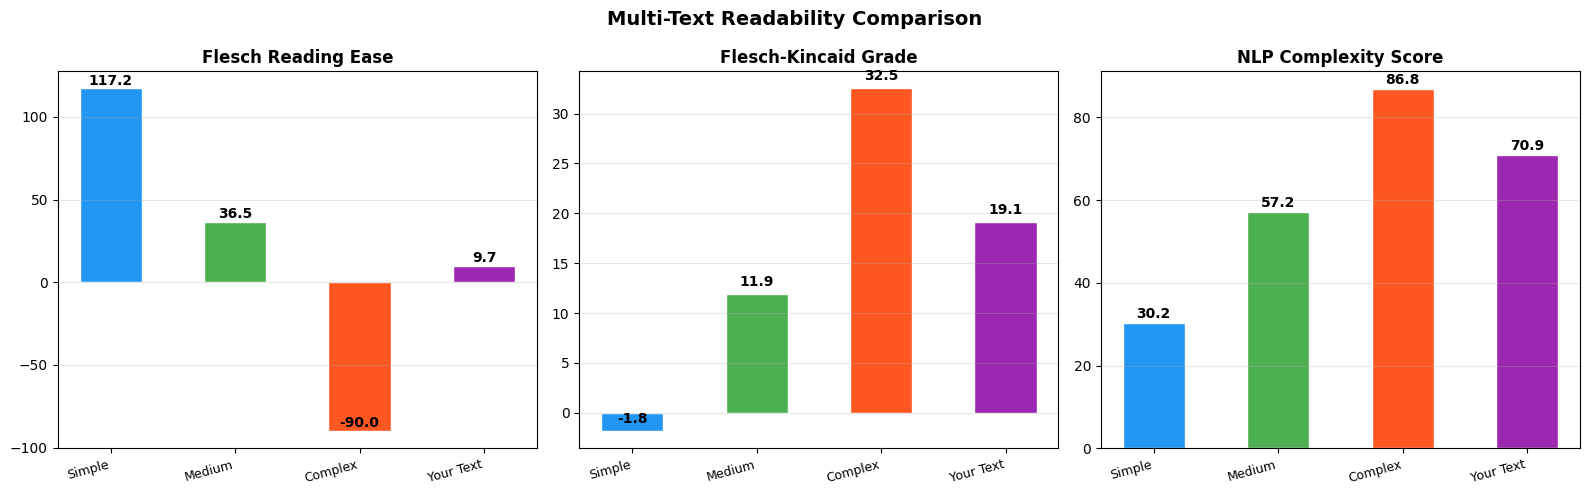

✅ Comparison chart saved!


In [9]:
texts = {
    'Simple':   'The cat sat on the mat. It was a big cat. The mat was red.',
    'Medium':   ('Machine learning is a method of data analysis that automates analytical model building. '
                 'It is based on the idea that systems can learn from data, identify patterns and make decisions.'),
    'Complex':  ('The epistemological ramifications of quantum mechanical indeterminacy necessitate a '
                 'fundamental reconceptualization of classical deterministic frameworks, insofar as '
                 'probabilistic superposition states preclude the unambiguous specification of conjugate variables.'),
    'Your Text': text[:400]
}

comparison_data = []
for label, t in texts.items():
    s = ReadabilityScorer(t)
    comparison_data.append({
        'Text':          label,
        'Flesch Ease':   s.flesch_reading_ease(),
        'FK Grade':      s.flesch_kincaid_grade(),
        'Fog Index':     s.gunning_fog(),
        'NLP Score':     s.nlp_complexity_score(),
        'Lex Diversity': round(s.lexical_diversity(), 3)
    })

df = pd.DataFrame(comparison_data).set_index('Text')
print('\n📊 Multi-Text Comparison:')
print(df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = ['#2196F3','#4CAF50','#FF5722','#9C27B0']

for ax, col, title in zip(
    axes,
    ['Flesch Ease', 'FK Grade', 'NLP Score'],
    ['Flesch Reading Ease', 'Flesch-Kincaid Grade', 'NLP Complexity Score']
):
    bars = ax.bar(df.index, df[col], color=palette, edgecolor='white', width=0.5)
    for bar, val in zip(bars, df[col]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(df.index, rotation=15, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Multi-Text Readability Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparison chart saved!')

In [10]:
flat = {}
for section, metrics in report.items():
    for k, v in metrics.items():
        flat[k] = v

results_df = pd.DataFrame([flat]).T.reset_index()
results_df.columns = ['Metric', 'Value']
results_df.to_csv('readability_results.csv', index=False)
print('✅ Results exported to readability_results.csv')
print(results_df.to_string(index=False))

✅ Results exported to readability_results.csv
                       Metric               Value
                  Total Words                 132
              Total Sentences                   6
              Total Syllables                 280
 Complex Words (3+ syllables)                  50
          Avg Sentence Length                22.0
              Avg Word Length                6.34
      Lexical Diversity (TTR)              0.6364
               Named Entities                   2
          Noun Phrase Density                7.17
          Passive Voice Ratio              0.1667
          Flesch Reading Ease              1.6375
         Flesch-Kincaid Grade           18.620556
            Gunning Fog Index           24.407407
                   SMOG Index            20.10791
           Coleman-Liau Index           20.348148
  Automated Readability Index           21.185111
             Dale-Chall Score           13.758648
NLP Complexity Score (Custom)                65.3
    